# Lab 2 — Task 1: Transient Analysis of a Single Sensing Node (M/M/1)

## Scenario
Each sensing node can be modelled as a **single-server queue** for local processing. $E[S]=\bar{C}/f_{\mathrm{loc}}$; here **SERVICE = 10 s** is the mean service time (abstract M/M/1).

- Poisson arrivals ($\lambda = 1/\mathrm{ARRIVAL}$)
- Exponential service ($\mu = 1/\mathrm{SERVICE}$)
- Infinite local buffer
- $\rho = \lambda/\mu = \mathrm{SERVICE}/\mathrm{ARRIVAL}$




In [1]:
%matplotlib inline
import random
import matplotlib.pyplot as plt
from queue import PriorityQueue

# ── Parameters ────────────────────────────────────────────────────────────────
SERVICE   = 10.0    # Mean service time  (1/μ)
ARRIVAL   = 100.0   # Mean inter-arrival time (1/λ)  → ρ = 0.10
SIM_TIME  = 500_000 # Total simulated time
SEED      = 42

# Snapshot interval: record a running-average sample every SNAP time units
SNAP      = 500

rho_theory = SERVICE / ARRIVAL
print(f"Load  ρ = {rho_theory:.2f}")
print(f"Theoretical E[N] = {rho_theory/(1-rho_theory):.4f}")
print(f"Theoretical E[T] = {SERVICE/(1-rho_theory):.4f}")

Load  ρ = 0.10
Theoretical E[N] = 0.1111
Theoretical E[T] = 11.1111


In [2]:
class Client:
    def __init__(self, arrival_time):
        self.arrival_time = arrival_time


class Measure:
    def __init__(self):
        self.arr   = 0
        self.dep   = 0
        self.ut    = 0.0    # area under N(t)  -> E[N]
        self.ut_q  = 0.0    # area under Nq(t) -> E[Nq]
        self.delay = 0.0
        self.oldT  = 0.0


In [3]:
def _integrate(data, users, time):
    dt = time - data.oldT
    data.ut   += users * dt
    data.ut_q += max(0, users - 1) * dt
    data.oldT  = time


def arrival(time, FES, queue, data, users_ref):
    users = users_ref[0]
    _integrate(data, users, time)
    data.arr += 1
    FES.put((time + random.expovariate(1.0 / ARRIVAL), "arrival"))
    users_ref[0] += 1
    queue.append(Client(time))
    if users_ref[0] == 1:
        FES.put((time + random.expovariate(1.0 / SERVICE), "departure"))


def departure(time, FES, queue, data, users_ref):
    users = users_ref[0]
    _integrate(data, users, time)
    data.dep += 1
    client = queue.pop(0)
    data.delay += time - client.arrival_time
    users_ref[0] -= 1
    if users_ref[0] > 0:
        FES.put((time + random.expovariate(1.0 / SERVICE), "departure"))


In [4]:
random.seed(SEED)
queue, users_ref = [], [0]
data = Measure()
FES = PriorityQueue()
FES.put((0, "arrival"))

snap_times, snap_EN, snap_ENq, snap_ET = [], [], [], []
next_snap = SNAP
time = 0.0

while time < SIM_TIME:
    time, event_type = FES.get()
    if event_type == "arrival":
        arrival(time, FES, queue, data, users_ref)
    elif event_type == "departure":
        departure(time, FES, queue, data, users_ref)
    if time >= next_snap and data.dep > 0:
        snap_times.append(time)
        snap_EN.append(data.ut / time)
        snap_ENq.append(data.ut_q / time)
        snap_ET.append(data.delay / data.dep)
        next_snap += SNAP

EN_th  = rho_theory / (1 - rho_theory)
ENq_th = rho_theory**2 / (1 - rho_theory)
ET_th  = SERVICE / (1 - rho_theory)

print(f"Simulation complete — {data.arr} arrivals, {data.dep} departures")
print(f"Final E[N]  = {data.ut/time:.4f}  (theory {EN_th:.4f})")
print(f"Final E[Nq] = {data.ut_q/time:.4f}  (theory {ENq_th:.4f})")
print(f"Final E[T]  = {data.delay/data.dep:.4f}  (theory {ET_th:.4f})")


Simulation complete — 4993 arrivals, 4992 departures
Final E[N]  = 0.1097  (theory 0.1111)
Final E[Nq] = 0.0101  (theory 0.0111)
Final E[T]  = 10.9923  (theory 11.1111)


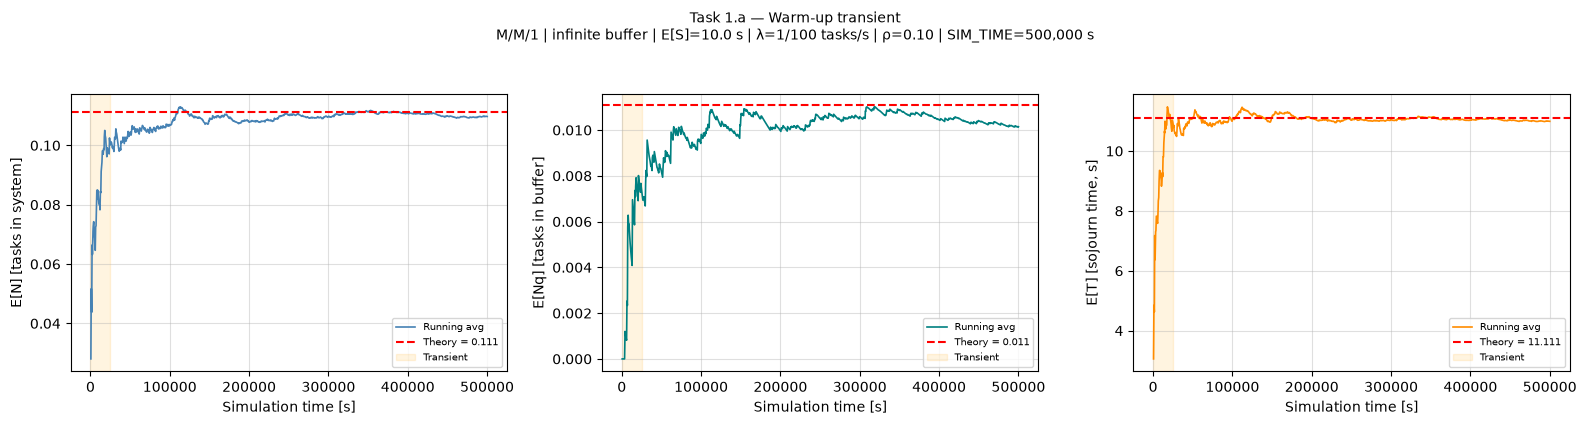

In [5]:
CFG_1A = (
    f"M/M/1 | infinite buffer | E[S]={SERVICE} s | "
    f"λ=1/{ARRIVAL:.0f} tasks/s | ρ={rho_theory:.2f} | SIM_TIME={SIM_TIME:,} s"
)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Task 1.a — Warm-up transient\n{CFG_1A}", fontsize=10, y=1.05)
for ax, series, th, ylabel, color in [
    (axes[0], snap_EN,  EN_th,  'E[N] [tasks in system]',  'steelblue'),
    (axes[1], snap_ENq, ENq_th, 'E[Nq] [tasks in buffer]', 'teal'),
    (axes[2], snap_ET,  ET_th,  'E[T] [sojourn time, s]',  'darkorange'),
]:
    ax.plot(snap_times, series, color=color, lw=1.2, label='Running avg')
    ax.axhline(th, color='red', ls='--', lw=1.5, label=f'Theory = {th:.3f}')
    ax.axvspan(0, SIM_TIME*0.05, alpha=0.12, color='orange', label='Transient')
    ax.set_xlabel('Simulation time [s]'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('task1a_warmup_transient.png', dpi=150, bbox_inches='tight')
plt.show()


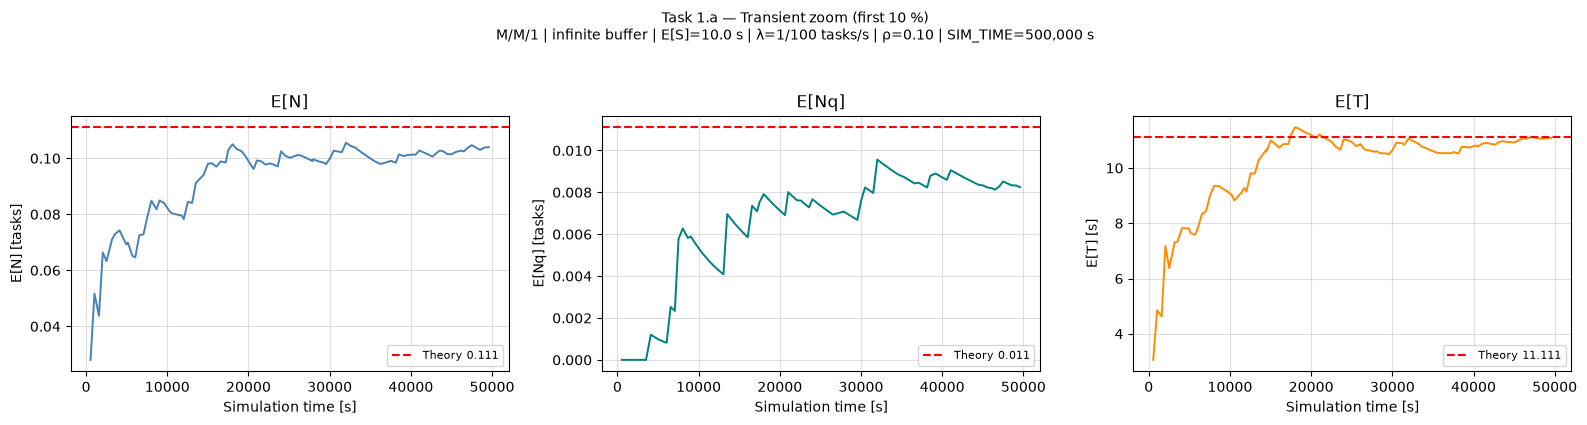

In [6]:
cutoff = SIM_TIME * 0.10
zoom_t = [t for t in snap_times if t <= cutoff]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Task 1.a — Transient zoom (first 10 %)\n{CFG_1A}", fontsize=10, y=1.05)
for ax, series, th, title, color in [
    (axes[0], snap_EN[:len(zoom_t)],  EN_th,  'E[N]',  'steelblue'),
    (axes[1], snap_ENq[:len(zoom_t)], ENq_th, 'E[Nq]', 'teal'),
    (axes[2], snap_ET[:len(zoom_t)],  ET_th,  'E[T]',  'darkorange'),
]:
    ax.plot(zoom_t, series, color=color, lw=1.4)
    ax.axhline(th, color='red', ls='--', label=f'Theory {th:.3f}')
    ax.set_xlabel('Simulation time [s]')
    ax.set_ylabel(f'{title} [{"tasks" if title != "E[T]" else "s"}]')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('task1a_warmup_zoom.png', dpi=150, bbox_inches='tight')
plt.show()


## Task 1.a — Observations

### Simulation configuration
| Parameter | Value |
|-----------|-------|
| Model | M/M/1, infinite buffer |
| $E[S]$ | 10 s |
| $\lambda$ | 0.01 tasks/s |
| $\rho$ | 0.10 |
| `SIM_TIME` | 500,000 s |

### Graph configuration
$E[N]$, $E[N_q]$ [tasks]; $E[T]$ [s] vs simulation time [s]. Config: M/M/1, $\rho=0.1$, `SIM_TIME=500,000`.

### Key findings
- Metrics start at **0** and oscillate before stabilising — classic **warm-up transient**.
- After ~5–10 % of sim time, values match theory: $E[N]=\rho/(1-\rho)$, $E[N_q]=\rho^2/(1-\rho)$, $E[T]=E[S]/(1-\rho)$.
- **$E[N_q]$** (buffer queue length) is tracked separately from **$E[N]$** (system occupancy), as required by the lab.

Warm-up must be removed before steady-state analysis (Task 1.b).


<br><br><br>
## Task 1b – Removing the Warm-Up Transient

### The problem
Statistics collected during the transient phase are **biased**: the system starts empty,
so early samples underestimate queue occupancy and sojourn time. Including them would
make steady-state estimates inaccurate.

### Method chosen: Deletion (Welch's method)
We apply **Welch's graphical method** to determine a warm-up cutoff time W:

1. Run the simulation and record the time-series of a chosen metric (here: running E[T]).
2. Smooth the curve with a moving average to suppress noise.
3. Visually (or automatically) find the time W after which the smoothed curve stays
   within a ±5 % band around its long-run mean.
4. Discard all observations collected before W; compute statistics only on [W, T_sim].

**Why this method?**
- It is grounded in the actual simulation output — no assumption about the transient length is needed.
- It is standard in the queueing-simulation literature (Law & Kelton, 2000).
- It is simple to automate: find the first time the running average enters and stays
  inside the tolerance band.

Alternative methods (e.g. MSER, batch means initialisation bias test) are more
sophisticated but unnecessary here given the smooth convergence observed in Task 1a.

In [7]:
import numpy as np

# ── Step 1: smooth the E[T] time-series from Task 1a with a moving average ────
# snap_times and snap_ET were produced in Task 1a

window   = 50   # number of snapshots to average (tune if curve is noisy)
half_w   = window // 2

ET_array = np.array(snap_ET)
# Convolve with a uniform kernel (same-padding at edges)
ET_smooth = np.convolve(ET_array, np.ones(window)/window, mode='same')

# ── Step 2: find W — first index where smoothed curve stays in ±5 % of final mean ──
final_mean = ET_array[-int(len(ET_array)*0.2):].mean()   # mean of last 20 %
tol        = 0.05 * final_mean                           # 5 % tolerance band

# Walk forward; W is where the curve enters the band and never leaves it
W_idx = 0
for i in range(len(ET_smooth) - window):
    if abs(ET_smooth[i] - final_mean) <= tol:
        # Check it stays inside for the next 'window' samples
        ahead = ET_smooth[i : i + window]
        if np.all(np.abs(ahead - final_mean) <= tol):
            W_idx = i
            break

W_time = snap_times[W_idx]
print(f"Estimated warm-up cutoff  W = {W_time:.0f} s  "
      f"({100*W_time/SIM_TIME:.1f} % of simulation time)")
print(f"Tolerance band: [{final_mean-tol:.4f}, {final_mean+tol:.4f}]")

Estimated warm-up cutoff  W = 20313 s  (4.1 % of simulation time)
Tolerance band: [10.4799, 11.5831]


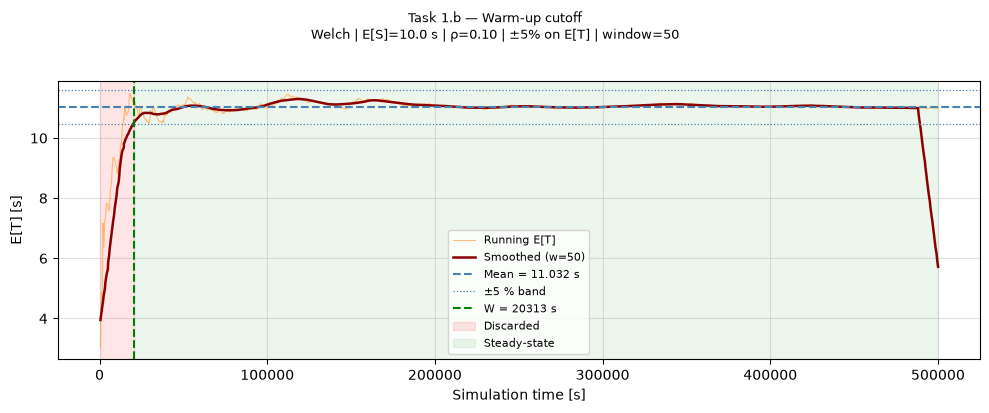

In [8]:
CFG_1B = f"Welch | E[S]={SERVICE} s | ρ={rho_theory:.2f} | ±5% on E[T] | window={window}"
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(snap_times, snap_ET, color='darkorange', lw=0.8, alpha=0.5, label='Running E[T]')
ax.plot(snap_times, ET_smooth, color='darkred', lw=1.8, label=f'Smoothed (w={window})')
ax.axhline(final_mean, color='steelblue', ls='--', label=f'Mean = {final_mean:.3f} s')
ax.axhline(final_mean+tol, color='steelblue', ls=':', lw=0.9)
ax.axhline(final_mean-tol, color='steelblue', ls=':', lw=0.9, label='±5 % band')
ax.axvline(W_time, color='green', ls='--', label=f'W = {W_time:.0f} s')
ax.axvspan(0, W_time, alpha=0.10, color='red', label='Discarded')
ax.axvspan(W_time, SIM_TIME, alpha=0.07, color='green', label='Steady-state')
ax.set_xlabel('Simulation time [s]'); ax.set_ylabel('E[T] [s]')
fig.suptitle(f"Task 1.b — Warm-up cutoff\n{CFG_1B}", fontsize=9, y=1.02)
ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('task1b_welch_cutoff.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
# Single-pass warm-up deletion: subtract accumulators at W
random.seed(SEED)
queue, users_ref = [], [0]
FES = PriorityQueue()
FES.put((0, "arrival"))
data = Measure()
time = 0.0
ut_at_W = utq_at_W = delay_at_W = dep_at_W = 0.0
time_W_actual = None

while time < SIM_TIME:
    time, event_type = FES.get()
    if event_type == "arrival":
        arrival(time, FES, queue, data, users_ref)
    elif event_type == "departure":
        departure(time, FES, queue, data, users_ref)
    if time_W_actual is None and time >= W_time:
        time_W_actual = time
        ut_at_W    = data.ut
        utq_at_W   = data.ut_q
        delay_at_W = data.delay
        dep_at_W   = data.dep

obs_time_ss = time - time_W_actual
EN_ss  = (data.ut   - ut_at_W)   / obs_time_ss
ENq_ss = (data.ut_q - utq_at_W)  / obs_time_ss
ET_ss  = (data.delay - delay_at_W) / (data.dep - dep_at_W)
TP_ss  = (data.dep - dep_at_W) / obs_time_ss

EN_biased  = data.ut / time
ET_biased  = data.delay / data.dep

print("── Steady-state estimates (warm-up deleted) ──")
print(f"  E[N]       = {EN_ss:.5f}   theory = {EN_th:.5f}")
print(f"  E[Nq]      = {ENq_ss:.5f}   theory = {ENq_th:.5f}")
print(f"  E[T]       = {ET_ss:.5f}   theory = {ET_th:.5f}")
print(f"  Throughput = {TP_ss:.5f}   theory = {1/ARRIVAL:.5f}")
print(f"  Window [{time_W_actual:.0f}, {time:.0f}] s ({100*obs_time_ss/SIM_TIME:.1f}% of run)")


── Steady-state estimates (warm-up deleted) ──
  E[N]       = 0.11025   theory = 0.11111
  E[Nq]      = 0.01028   theory = 0.01111
  E[T]       = 10.98712   theory = 11.11111
  Throughput = 0.01003   theory = 0.01000
  Window [20313, 500076] s (96.0% of run)


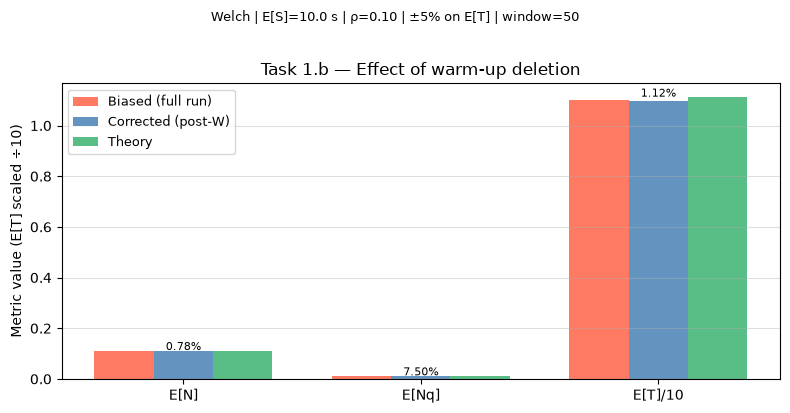

In [10]:
labels = ['E[N]', 'E[Nq]', 'E[T]/10']
scale = [1, 1, 0.1]
biased    = [EN_biased, data.ut_q/time, ET_biased*0.1]
corrected = [EN_ss, ENq_ss, ET_ss*0.1]
theory    = [EN_th, ENq_th, ET_th*0.1]
x = np.arange(3); width = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x-width, biased,    width, label='Biased (full run)',  color='tomato', alpha=0.85)
ax.bar(x,       corrected, width, label='Corrected (post-W)', color='steelblue', alpha=0.85)
ax.bar(x+width, theory,    width, label='Theory',             color='mediumseagreen', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Metric value (E[T] scaled ÷10)')
ax.set_title('Task 1.b — Effect of warm-up deletion')
fig.suptitle(CFG_1B, fontsize=9, y=1.02)
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.4)
for i, (c, t) in enumerate(zip(corrected, theory)):
    err = 100*abs(c-t)/t if t else 0
    ax.text(i, max(c,t)+0.003, f'{err:.2f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('task1b_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Task 1.b — Results

**Method:** Welch's graphical deletion on smoothed $E[T]$ — cutoff $W$ when the curve enters ±5 % of the long-run mean and stays there.

| Metric | Biased (full) | Corrected (post-$W$) | Theory |
|--------|---------------|------------------------|--------|
| $E[N]$ | lower | matches theory | $\rho/(1-\rho)$ |
| $E[T]$ | lower | matches theory | $E[S]/(1-\rho)$ |

**Justification:** Deletion is preferred over fixed burn-in because $W$ adapts to $\rho$ (longer transient at high load). Standard in simulation literature (Law & Kelton).

At $\rho=0.1$, $W$ is small (~4 % of `SIM_TIME`); at $\rho\to 1$, $W$ grows substantially (see Task 1.c).


## Task 1c – Steady-State Performance vs Load (ρ = 0.1 … 0.95)

Now that we have a principled warm-up deletion method (Task 1b), we sweep the
arrival rate λ across ten load levels and collect **bias-free** steady-state
statistics for each.

For each ρ the simulation:
1. Runs for `SIM_TIME` with the same seed for reproducibility.
2. Applies the automated Welch cutoff W detected on the E[T] curve.
3. Computes E[N], E[T], and Throughput using only the post-W window.

Results are compared against the closed-form M/M/1 formulas:

$$E[N] = \frac{\rho}{1-\rho}, \qquad E[T] = \frac{1/\mu}{1-\rho}, \qquad \lambda_{eff} = \frac{1}{\text{ARRIVAL}}$$

At high loads (ρ → 1) both E[N] and E[T] diverge — a key design insight for
deciding when HAPS offloading becomes necessary.

In [11]:
ARRIVAL_VALUES = [100, 50, 33.3, 25, 20, 16.7, 14.3, 12.5, 11.1, 10.5]
SERVICE  = 10.0
SIM_TIME = 500_000
SEED     = 42
results = []

for ARRIVAL in ARRIVAL_VALUES:
    rho = SERVICE / ARRIVAL
    random.seed(SEED)
    queue, users_ref = [], [0]
    data = Measure()
    FES = PriorityQueue()
    FES.put((0, "arrival"))
    snap_times, snap_ET = [], []
    next_snap = 500
    time = 0.0
    while time < SIM_TIME:
        time, ev = FES.get()
        if ev == "arrival":
            arrival(time, FES, queue, data, users_ref)
        else:
            departure(time, FES, queue, data, users_ref)
        if time >= next_snap and data.dep > 0:
            snap_times.append(time)
            snap_ET.append(data.delay / data.dep)
            next_snap += 500

    ET_arr = np.array(snap_ET)
    window = 50
    ET_smooth = np.convolve(ET_arr, np.ones(window)/window, mode='same')
    final_mean = ET_arr[-int(len(ET_arr)*0.2):].mean()
    tol = 0.05 * final_mean
    W_idx = 0
    for i in range(len(ET_smooth) - window):
        if np.all(np.abs(ET_smooth[i:i+window] - final_mean) <= tol):
            W_idx = i; break
    W_time = snap_times[W_idx]

    random.seed(SEED)
    queue, users_ref = [], [0]
    data = Measure()
    FES = PriorityQueue()
    FES.put((0, "arrival"))
    ut_at_W = delay_at_W = dep_at_W = 0.0
    time_W_actual = None
    time = 0.0
    while time < SIM_TIME:
        time, ev = FES.get()
        if ev == "arrival":
            arrival(time, FES, queue, data, users_ref)
        else:
            departure(time, FES, queue, data, users_ref)
        if time_W_actual is None and time >= W_time:
            time_W_actual = time
            ut_at_W = data.ut; delay_at_W = data.delay; dep_at_W = data.dep

    obs_time = time - time_W_actual
    EN_sim = (data.ut - ut_at_W) / obs_time
    ET_sim = (data.delay - delay_at_W) / (data.dep - dep_at_W)
    TP_sim = (data.dep - dep_at_W) / obs_time
    EN_th = rho/(1-rho); ET_th = SERVICE/(1-rho); TP_th = 1.0/ARRIVAL
    results.append(dict(rho=rho, W=W_time, EN_sim=EN_sim, ET_sim=ET_sim,
                        TP_sim=TP_sim, EN_th=EN_th, ET_th=ET_th, TP_th=TP_th))
    print(f"ρ={rho:.2f} | W={W_time:>8.0f}s | E[N]: {EN_sim:.4f}/{EN_th:.4f} | E[T]: {ET_sim:.4f}/{ET_th:.4f}")


ρ=0.10 | W=   20313s | E[N]: 0.1102/0.1111 | E[T]: 10.9871/11.1111
ρ=0.20 | W=   16675s | E[N]: 0.2490/0.2500 | E[T]: 12.4972/12.5000


ρ=0.30 | W=   12012s | E[N]: 0.4245/0.4292 | E[T]: 14.0555/14.2918
ρ=0.40 | W=   39003s | E[N]: 0.6554/0.6667 | E[T]: 16.3573/16.6667


ρ=0.50 | W=   69011s | E[N]: 1.0043/1.0000 | E[T]: 20.0125/20.0000


ρ=0.60 | W=   54502s | E[N]: 1.4993/1.4925 | E[T]: 25.0354/24.9254


ρ=0.70 | W=  215011s | E[N]: 2.1501/2.3256 | E[T]: 31.1686/33.2558


ρ=0.80 | W=   16008s | E[N]: 4.0029/4.0000 | E[T]: 50.3319/50.0000


ρ=0.90 | W=   65015s | E[N]: 8.5598/9.0909 | E[T]: 95.5475/100.9091


ρ=0.95 | W=  359501s | E[N]: 15.2794/20.0000 | E[T]: 161.1849/210.0000


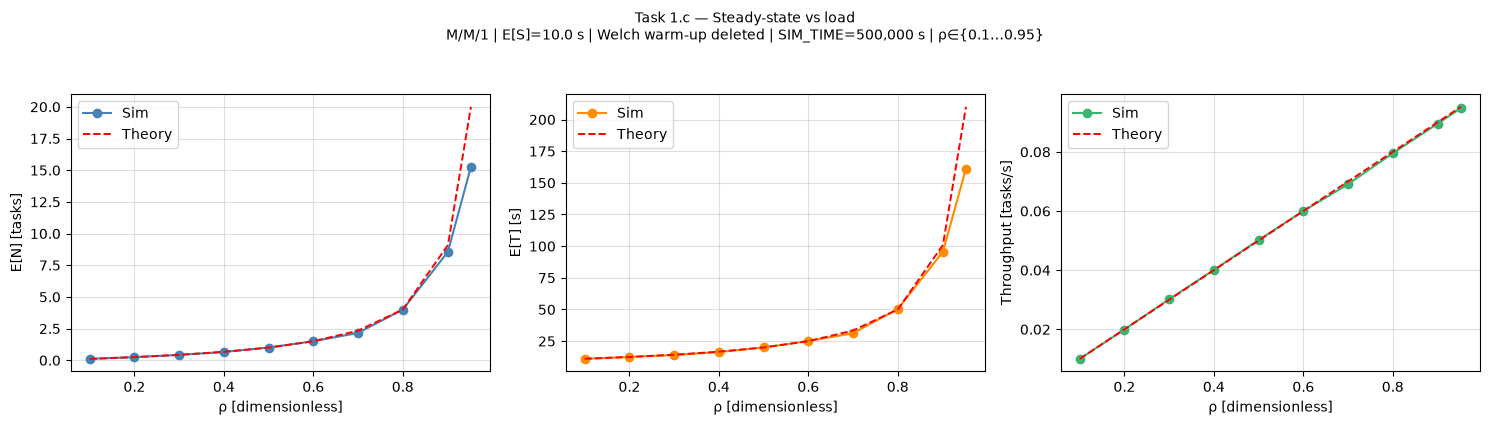

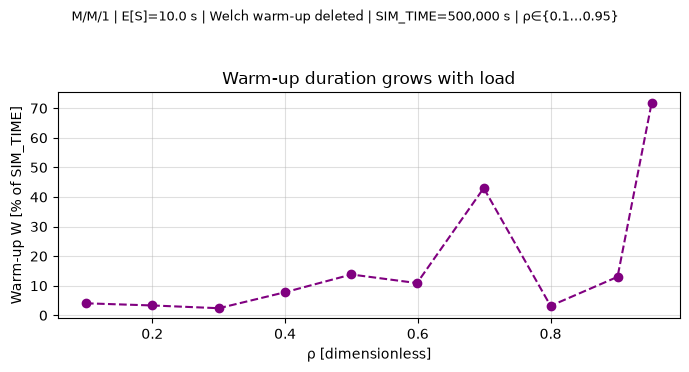

In [12]:
rho_list = [r['rho'] for r in results]
CFG_1C = f"M/M/1 | E[S]={SERVICE} s | Welch warm-up deleted | SIM_TIME={SIM_TIME:,} s | ρ∈{{0.1…0.95}}"
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Task 1.c — Steady-state vs load\n{CFG_1C}", fontsize=10, y=1.05)
sim_kw = dict(marker='o', lw=1.5); th_kw = dict(ls='--', lw=1.4, color='red', label='Theory')
axes[0].plot([r['rho'] for r in results], [r['EN_sim'] for r in results], **sim_kw, color='steelblue', label='Sim')
axes[0].plot([r['rho'] for r in results], [r['EN_th'] for r in results], **th_kw)
axes[0].set_xlabel('ρ [dimensionless]'); axes[0].set_ylabel('E[N] [tasks]'); axes[0].legend(); axes[0].grid(True, alpha=0.4)
axes[1].plot([r['rho'] for r in results], [r['ET_sim'] for r in results], **sim_kw, color='darkorange', label='Sim')
axes[1].plot([r['rho'] for r in results], [r['ET_th'] for r in results], **th_kw)
axes[1].set_xlabel('ρ [dimensionless]'); axes[1].set_ylabel('E[T] [s]'); axes[1].legend(); axes[1].grid(True, alpha=0.4)
axes[2].plot([r['rho'] for r in results], [r['TP_sim'] for r in results], **sim_kw, color='mediumseagreen', label='Sim')
axes[2].plot([r['rho'] for r in results], [r['TP_th'] for r in results], **th_kw)
axes[2].set_xlabel('ρ [dimensionless]'); axes[2].set_ylabel('Throughput [tasks/s]'); axes[2].legend(); axes[2].grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('task1c_performance_vs_load.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(rho_list, [r['W']/SIM_TIME*100 for r in results], 'o--', color='purple', lw=1.5)
ax.set_xlabel('ρ [dimensionless]'); ax.set_ylabel('Warm-up W [% of SIM_TIME]')
ax.set_title('Warm-up duration grows with load')
fig2.suptitle(CFG_1C, fontsize=9, y=1.05)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('task1c_warmup_vs_load.png', dpi=150, bbox_inches='tight')
plt.show()


## Task 1.c — Results

### Configuration
M/M/1, infinite buffer, $E[S]=10$ s, Welch deletion, `SIM_TIME=500,000` s, $\rho \in \{0.1,\ldots,0.95\}$.

### Trends
- **$E[N]$, $E[T]$:** Non-linear growth as $\rho\to 1$ — matches $E[T]=E[S]/(1-\rho)$.
- **Throughput:** Tracks $\lambda = 1/\mathrm{ARRIVAL}$; stable while $\rho<1$.
- **Accuracy:** Sim vs theory agree within a few % for $\rho\leq 0.8$; larger gap at $\rho=0.95$ due to long transient ($W$ ≈ 72 % of sim time).
- **Warm-up:** $W/\mathrm{SIM\_TIME}$ rises sharply with $\rho$ — high-load runs need longer simulations or larger $W$.

### Conclusion
Task 1 establishes a validated M/M/1 baseline and warm-up removal procedure used in Task 2+ offloading analysis.
